### Imports

In [61]:
import math
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colormaps

from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [62]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix ---
M_m = torch.tensor([[0.1, 0.02], [0.08, 0.01], [0.06, 0.01], [-0.06, -0.02], [-0.08, -0.01], [-0.1, -0.02]])

# --- Penalty coefficients ---
alpha, beta, gamma = 0.1, 5.0, 0.3

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
scale_factor = 10.0
perturbation_directions = {
    "Right": scale_factor * np.array([1.0, 0.0]), "Left": scale_factor * np.array([-1.0, 0.0]),
    "Up": scale_factor * np.array([0.0, 1.0]), "Down": scale_factor * np.array([0.0, -1.0]),
    "Up-Right": scale_factor * np.array([0.707, 0.707]), "Up-Left": scale_factor * np.array([-0.707, 0.707]),
    "Down-Left": scale_factor * np.array([-0.707, -0.707]), "Down-Right": scale_factor * np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.12, 0.10

### Neural Limb Controller

In [63]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_t, x_aff_t, y_s_delayed_t, G_s):
        """Perform a single forward step of the neural controller."""
        self.y_s = self.neural_activation_step(self.y_s, self.w_sr @ y_s_delayed_t + self.w_si @ u_fb_t + self.b_s)
        self.y_m = self.neural_activation_step(self.y_m, self.w_mr @ self.y_m + self.w_mi @ self.y_s + self.b_m)
        self.y_act = self.muscle_activation_step(self.y_act, self.w_act @ self.y_m + G_s * x_aff_t)
        return self.y_act

### Hill-type muscle model equations

In [64]:
class MuscleConstants:
    """Class to store physiologically based constants for muscle dynamics."""
    F_MAX = 1.0               # Maximum isometric force (used for normalization)
    L_OPT = 1.0               # Optimal fiber length (used for normalization)
    V_MAX = 10.0              # Maximum shortening velocity (V_max / L_opt)

    # Coefficients for Shortening
    A_HILL = 0.25             # Normalized coefficient 'a/F_max'
    B_HILL = A_HILL * V_MAX   # Normalized coefficient 'b/L_opt'

    # Coefficients for Lengthening
    K_ECC = 0.15              # Shape factor for the eccentric regime
    F_MAX_ECC = 1.4           # Max force during lengthening (1.4 * F_max)


class ForceLength:
    """Class to compute the force-length relationship for muscles."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4):
        """
        Args:
            L_m (torch.Tensor): Normalized muscle length.
            L_opt (float): Optimal fiber length (default: 1.0).
            width_factor (float): Controls the width of the bell curve (default: 0.4).

        Returns:
            torch.Tensor: Force-Length scaling factor (FL).
        """
        exp = -((L_m - L_opt) / width_factor).pow(2)
        return torch.exp(exp)


class ForceVelocity:
    """Class to compute the force-velocity relationship for muscles."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """
        Args:
            dLm_dt (torch.Tensor): Normalized muscle velocity (positive for lengthening, negative for shortening).
            V_max (float): Maximum shortening velocity.
            A_hill (float): Hill's coefficient 'a/F_max'.
            B_hill (float): Hill's coefficient 'b/L_opt'.
            F_max_ecc (float): Max force during lengthening.
            K_ecc (float): Shape factor for the eccentric regime.

        Returns:
            torch.Tensor: Force-Velocity scaling factor (FV).
        """
        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt)
        # Lengthening (dLm_dt > 0): Exponential plateau
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        # Combine shortening and lengthening regimes
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Cost functions

In [65]:
def compute_costs(controller, qpos, qvel, F_m, target_qpos):
    """Compute the neural, force, and kinematic costs."""
    # Neural cost (Instantaneous mean of squared activity)
    neural_cost = controller.y_s.pow(2).mean() + controller.y_m.pow(2).mean()

    # Force output cost (Instantaneous mean of squared force)
    force_cost = F_m.pow(2).mean()

    # Ensure target_qpos and qvel are tensors
    target_qpos = torch.tensor(target_qpos, dtype=qpos.dtype, device=qpos.device) if not isinstance(target_qpos, torch.Tensor) else target_qpos
    qvel = qvel if isinstance(qvel, torch.Tensor) else torch.tensor(qvel, dtype=qpos.dtype, device=qpos.device)

    # Kinematic cost (Instantaneous deviation from target position and velocity)
    kinematic_cost = (qpos - target_qpos).pow(2).mean() + 0.5 * qvel.pow(2).mean()

    return neural_cost, force_cost, kinematic_cost, target_qpos, qvel

def compute_weighted_costs(neural_cost, force_cost, kinematic_cost, alpha, beta, gamma):
    """Compute weighted components of the cost."""
    return {
        "neural": alpha * neural_cost,
        "force": beta * force_cost,
        "kinematic": gamma * kinematic_cost,
        "total": alpha * neural_cost + beta * force_cost + gamma * kinematic_cost,
    }

def compute_and_accumulate_costs(controller, qpos, qvel, F_m, target_qpos, total_costs, alpha, beta, gamma):
    """Compute costs, apply weights, and accumulate them into total_costs."""
    # Compute costs
    neural_cost, force_cost, kinematic_cost, target_qpos, qvel = compute_costs(controller, qpos, qvel, F_m, target_qpos)
    weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, alpha, beta, gamma)

    # Add L2 regularization to the total cost
    total_cost = weighted_costs["total"]
    l2_reg = 0.01 * sum(p.pow(2).sum() for p in controller.parameters())
    total_cost += l2_reg

    # Accumulate costs
    for key in total_costs:
        total_costs[key] += weighted_costs[key].item()

    return total_cost

### Helper functions

In [66]:
def compute_jacobian(theta_s, theta_e, l1, l2):
    """Compute the Jacobian matrix for a 2D planar arm."""
    J = np.array([
        [-l1 * np.sin(theta_s) - l2 * np.sin(theta_s + theta_e), -l2 * np.sin(theta_s + theta_e)],
        [l1 * np.cos(theta_s) + l2 * np.cos(theta_s + theta_e),  l2 * np.cos(theta_s + theta_e)]
    ])
    return J

### Training Loop

In [67]:
# Initialize environment and controller
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

# Set up optimizer and scheduler
optimizer = torch.optim.Adam(controller.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

In [68]:
# Initialize target_results
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}

# Training loop
num_epochs = 20
epoch_metadata = []
epoch_qpos_over_time = []
epoch_external_loads = []
epoch_costs_over_time = []

for epoch in range(num_epochs):
    # Reset controller and environment
    controller.reset_weights()
    controller.reset_states()
    obs, _ = env.reset(target_qpos=(0.0, 0.0))

    # Randomly select load condition and perturbation direction
    background_load = random.choice([background_load_low, background_load_high])
    load_condition = "High" if background_load == background_load_high else "Low"
    G_s = G_s_high if background_load == background_load_high else G_s_low
    perturbation_idx = random.randint(0, len(perturbation_directions) - 1)
    direction_name = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"][perturbation_idx]
    epoch_metadata.append({"load": load_condition, "direction": direction_name})

    print(f"Epoch {epoch + 1}/{num_epochs}, Load Condition: {load_condition}, Perturbation Direction: {direction_name}")

    # Initialize accumulators and buffers
    J_b_1_accumulated = torch.tensor(0.0, requires_grad=True)
    J_b_2_accumulated = torch.tensor(0.0, requires_grad=True)
    J_p_accumulated = torch.tensor(0.0, requires_grad=True)
    total_costs = {"neural": 0.0, "force": 0.0, "kinematic": 0.0, "total": 0.0}
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]

    pose_errors, rewards = [], []
    qpos_over_time, external_load_over_time = [], []
    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}

    # Initialize muscle kinematics
    L_m = torch.tensor([1.05, 1.02, 1.00, 0.98, 0.97, 0.99], requires_grad=True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]

    # Initialize previous pose error
    previous_pose_error = None

    for step in range(T_step):
        # Detach internal states
        for state in [controller.y_s, controller.y_m, controller.y_act]:
            state.detach_()

        # Get current observation
        theta_s, theta_e = obs[0], obs[2]

        # Compute Jacobian
        J = compute_jacobian(theta_s, theta_e, l1, l2)

        # Determine external torque based on the current phase
        if step < Tb_step:
            desired_force = np.array([0.0, 0.0])
        elif Tb_step <= step < Tp_step:
            desired_force = background_load * perturbation_directions[direction_name]
        elif Tp_step <= step < Tsp_step:
            desired_force = (background_load + perturbation_load) * perturbation_directions[direction_name]
        else:
            desired_force = background_load * perturbation_directions[direction_name]

        tau = J.T @ desired_force

        env.set_external_torque(tau)
        external_load_over_time.append(tau.copy())

        # Compute pose error
        target_qpos = (0.0, 0.0)
        pose_error = np.sqrt((target_qpos[0] - obs[0])**2 + (target_qpos[1] - obs[2])**2)
        
        # Compute kinematic loss term
        kinematic_loss_term = (torch.tensor(obs[:2]) - torch.tensor(target_qpos)).pow(2).mean() + 0.5 * torch.tensor(obs[1:3]).pow(2).mean()

        # Compute muscle length changes
        dLm_dt = (-M_m @ torch.tensor(obs[1:3], dtype=torch.float32).unsqueeze(1)).squeeze()
        new_L_m = L_m + dLm_dt * dt
        new_L_m, dLm_dt = new_L_m.detach(), dLm_dt.detach()

        # Update muscle kinematics
        new_delta_L_m = new_L_m - L_m_initial
        new_velocity_L_m = dLm_dt
        new_acceleration_L_m = (new_velocity_L_m - velocity_L_m) / dt
        new_jerk_L_m = (new_acceleration_L_m - acceleration_L_m) / dt

        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = new_L_m, new_delta_L_m, new_velocity_L_m, new_acceleration_L_m, new_jerk_L_m
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        x_aff_t = G_aff @ x_m.T

        # Compute muscle forces and feedback
        FL = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze())
        F_m = delayed_activations * FL * FV

        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)  # Joint positions
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)  # Joint velocities
        position_error = G_p * (qpos - torch.tensor(target_qpos, dtype=torch.float32))
        velocity_feedback = G_d * qvel
        force_feedback = G_f * F_m
        u_fb = torch.cat([position_error, velocity_feedback, force_feedback], dim=0)

        # Generate muscle activations
        u_fb_t = u_fb
        muscle_activations = controller.forward_step(u_fb_t=u_fb_t, x_aff_t=x_aff_t, y_s_delayed_t=controller.y_s, G_s=G_s)

        # Apply activation delay
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)

        # Compute and accumulate costs
        total_cost = compute_and_accumulate_costs(controller, qpos, qvel, F_m, target_qpos, total_costs, alpha, beta, gamma)

        # Compute individual costs for logging
        neural_cost, force_cost, kinematic_cost, target_qpos, qvel = compute_costs(controller, qpos, qvel, F_m, target_qpos)
        weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, alpha, beta, gamma)

        # Scale the costs for debugging
        scaled_weighted_costs = {key: value for key, value in weighted_costs.items()}

        # Store step-by-step costs
        for key in epoch_costs.keys():
            epoch_costs[key].append(scaled_weighted_costs[key])

        # Backpropagation
        optimizer.zero_grad()
        total_cost.backward()
        torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
        optimizer.step()

        # Step the environment
        obs, reward, terminated, truncated, info = env.step(muscle_activations.detach().numpy())
        pose_errors.append(pose_error)
        rewards.append(reward)
        x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2])
        y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2])
        qpos_over_time.append((x, y))

        if terminated or truncated:
            break

        if len(pose_errors) > 0 and len(rewards) > 0:
            if len(target_results[perturbation_idx]["pose_errors"]) < epoch + 1:
                target_results[perturbation_idx]["pose_errors"].append(pose_errors)
                target_results[perturbation_idx]["rewards"].append(rewards)

    # Store epoch results
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_external_loads.append(external_load_over_time)
    epoch_costs_over_time.append(epoch_costs) 

    # Store epoch results
    if len(pose_errors) > 0 and len(rewards) > 0:
        target_results[perturbation_idx]["pose_errors"].append(pose_errors)
        target_results[perturbation_idx]["rewards"].append(rewards)
        for key in epoch_costs.keys():
            target_results[perturbation_idx]["costs"][key].append(total_costs[key])

    # Post-epoch processing
    scheduler.step()

Epoch 1/20, Load Condition: High, Perturbation Direction: Right
Epoch 2/20, Load Condition: Low, Perturbation Direction: Up-Left
Epoch 3/20, Load Condition: Low, Perturbation Direction: Right
Epoch 4/20, Load Condition: Low, Perturbation Direction: Down
Epoch 5/20, Load Condition: Low, Perturbation Direction: Up
Epoch 6/20, Load Condition: High, Perturbation Direction: Right
Epoch 7/20, Load Condition: High, Perturbation Direction: Down-Left
Epoch 8/20, Load Condition: Low, Perturbation Direction: Up
Epoch 9/20, Load Condition: High, Perturbation Direction: Up-Right
Epoch 10/20, Load Condition: High, Perturbation Direction: Down
Epoch 11/20, Load Condition: Low, Perturbation Direction: Right
Epoch 12/20, Load Condition: Low, Perturbation Direction: Down
Epoch 13/20, Load Condition: High, Perturbation Direction: Down
Epoch 14/20, Load Condition: High, Perturbation Direction: Right
Epoch 15/20, Load Condition: High, Perturbation Direction: Left
Epoch 16/20, Load Condition: Low, Perturbat

### Plots

In [69]:
# Define perturbation direction names
perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]

# Group results by load condition and perturbation direction
low_load_results = {}
high_load_results = {}

for epoch_idx, metadata in enumerate(epoch_metadata):
    perturbation_idx = perturbation_names.index(metadata["direction"])
    if perturbation_idx >= len(target_results):
        continue

for epoch_idx, metadata in enumerate(epoch_metadata):
    perturbation_idx = perturbation_names.index(metadata["direction"])
    if epoch_idx >= len(target_results[perturbation_idx]["pose_errors"]):
        continue

    key = (metadata["load"], perturbation_idx)
    if metadata["load"] == "Low":
        if key not in low_load_results:
            low_load_results[key] = {"pose_errors": [], "rewards": []}
        low_load_results[key]["pose_errors"].append(target_results[perturbation_idx]["pose_errors"][epoch_idx])
        low_load_results[key]["rewards"].append(target_results[perturbation_idx]["rewards"][epoch_idx])

    elif metadata["load"] == "High":
        if key not in high_load_results:
            high_load_results[key] = {"pose_errors": [], "rewards": []}
        high_load_results[key]["pose_errors"].append(target_results[perturbation_idx]["pose_errors"][epoch_idx])
        high_load_results[key]["rewards"].append(target_results[perturbation_idx]["rewards"][epoch_idx])

In [70]:
def pad_and_compute_mean_std(data, max_length):
    """Pad data with NaN to the maximum length and compute mean and standard deviation."""
    padded_data = np.array([np.pad(epoch, (0, max_length - len(epoch)), constant_values=np.nan) for epoch in data])
    mean = np.nanmean(padded_data, axis=0)
    std = np.nanstd(padded_data, axis=0)
    return mean, std

def plot_mean_and_std(ax, x, mean, std, label, color, line_style="solid", alpha=0.1):
    """Plot mean and standard deviation as a shaded region."""
    ax.plot(x, mean, label=label, color=color, linestyle=line_style)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)

def plot_pose_error(ax, grouped_results):
    """Plot pose error over time for all perturbations."""
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_names)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for (load, perturbation_idx), perturbation_data in grouped_results.items():
        pose_errors = perturbation_data["pose_errors"]
        if not pose_errors:
            continue

        max_length = max(len(epoch) for epoch in pose_errors)
        if len(pose_errors) > 1:  # If multiple trials exist, compute mean and std
            mean, std = pad_and_compute_mean_std(pose_errors, max_length)
            label = f"{perturbation_names[perturbation_idx]} ({load})"
            color = colormap(perturbation_idx / num_perturbations)
            plot_mean_and_std(ax, range(len(mean)), mean, std, label=label, color=color)
        else:  # If only one trial exists, plot it directly
            single_trial = np.pad(pose_errors[0], (0, max_length - len(pose_errors[0])), constant_values=np.nan)
            label = f"{perturbation_names[perturbation_idx]} ({load})"
            color = colormap(perturbation_idx / num_perturbations)
            ax.plot(range(len(single_trial)), single_trial, label=label, color=color)

    ax.set_title("Pose error over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Pose error")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_reward(ax, perturbation_results):
    """Plot reward over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_names)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for (load, perturbation_idx), perturbation_data in perturbation_results.items():
        rewards = perturbation_data["rewards"]
        if not rewards:
            continue

        max_length = max(len(epoch) for epoch in rewards)
        mean, std = pad_and_compute_mean_std(rewards, max_length)
        color = colormap(perturbation_idx / num_perturbations)  # Use the direction index
        label = f"{perturbation_names[perturbation_idx]} ({load})"  # Include load in the label
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=label, color=color)
    
    ax.set_title("Reward over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Reward")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_costs(ax, epoch_costs_over_time):
    """Plot aggregated cost components over time (mean and std) for all epochs."""
    cost_keys = ["neural", "force", "kinematic", "total"]
    colors = {"neural": "orange", "force": "cyan", "kinematic": "blue", "total": "red"} 
    line_styles = {"total": "--"}

    # Initialize storage for all costs across epochs
    all_costs = {key: [] for key in cost_keys}

    # Collect costs for all epochs
    for epoch_costs in epoch_costs_over_time:
        for key in cost_keys:
            # Detach tensors and convert to NumPy arrays
            cost_values = [value.detach().numpy() if isinstance(value, torch.Tensor) else value for value in epoch_costs[key]]
            all_costs[key].append(cost_values)

    # Compute mean and std for each cost component
    for key in cost_keys:
        max_length = max(len(epoch) for epoch in all_costs[key])  # Find the maximum length across epochs
        mean, std = pad_and_compute_mean_std(all_costs[key], max_length)  # Pad and compute mean/std

        # Plot mean and std
        line_style = line_styles.get(key, "solid")  # Use "dashed" for "total", "solid" for others
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=f"{key.capitalize()} Cost", color=colors[key], line_style=line_style, alpha=0.2)

    ax.set_title("Aggregated Cost Components Over Time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Cost")
    ax.legend()
    ax.grid()

def plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads):
    """
    Plot torque and position data for selected epochs, grouped by one randomly selected direction.

    Parameters:
        epoch_metadata (list): List of dictionaries containing metadata for each epoch.
        epoch_qpos_over_time (list): List of (x, y) positions over time for each epoch.
        epoch_external_loads (list): List of external torque data for each epoch.
    """
    # Define the directions and load conditions
    directions = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    load_conditions = ["Low", "High"]

    # Shuffle directions to try them in random order
    random.shuffle(directions)

    for selected_direction in directions:
        # Group epochs by direction and load condition
        epochs_by_direction_and_load = {load: [] for load in load_conditions}
        for epoch, metadata in enumerate(epoch_metadata):
            direction = metadata["direction"]
            load = metadata["load"]
            if direction == selected_direction and load in epochs_by_direction_and_load:
                epochs_by_direction_and_load[load].append(epoch)

        # Check available loads
        low_epochs = epochs_by_direction_and_load["Low"]
        high_epochs = epochs_by_direction_and_load["High"]

        if not low_epochs and not high_epochs:  # No data for this direction
            continue  # Try the next direction

        # Create the figure and axes
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # Two plots: torque and position
        ax_torque, ax_position = axes

        # Add a common title for the plots
        fig.suptitle(
            f"Torques and End-Effector Trajectory - {selected_direction}",
            fontsize=14, fontweight="bold"
        )

        # Plot for Low Load if available
        if low_epochs:
            low_epoch = random.choice(low_epochs)
            external_load_low = np.array(epoch_external_loads[low_epoch])
            ax_torque.plot(external_load_low[:, 0], label="Shoulder Torque (Low Load)", linestyle="-", color="cyan")
            ax_torque.plot(external_load_low[:, 1], label="Elbow Torque (Low Load)", linestyle="-", color="orange")
            qpos_x_low, qpos_y_low = zip(*epoch_qpos_over_time[low_epoch])
            ax_position.plot(qpos_x_low, qpos_y_low, label="Trajectory (Low Load)", linestyle="-", color="green")
            ax_position.scatter(qpos_x_low[-1], qpos_y_low[-1], color="green", label="Final Position (Low Load)")

        # Plot for High Load if available
        if high_epochs:
            high_epoch = random.choice(high_epochs)
            external_load_high = np.array(epoch_external_loads[high_epoch])
            ax_torque.plot(external_load_high[:, 0], label="Shoulder Torque (High Load)", linestyle="-", color="blue")
            ax_torque.plot(external_load_high[:, 1], label="Elbow Torque (High Load)", linestyle="-", color="red")
            qpos_x_high, qpos_y_high = zip(*epoch_qpos_over_time[high_epoch])
            ax_position.plot(qpos_x_high, qpos_y_high, label="Trajectory (High Load)", linestyle=(0, (1, 3)), color="red")
            ax_position.scatter(qpos_x_high[0], qpos_y_high[0], color="blue", label="Initial Position")
            ax_position.scatter(qpos_x_high[-1], qpos_y_high[-1], color="red", label="Final Position (High Load)")

        # Finalize the plots
        ax_torque.set_xlabel("Time Steps")
        ax_torque.set_ylabel("Torque")
        ax_torque.legend()
        ax_torque.grid()

        ax_position.set_xlabel("X Position")
        ax_position.set_ylabel("Y Position")
        ax_position.legend()
        ax_position.grid()

        plt.tight_layout(pad=2.0)
        plt.show()
        return

    print("No direction had enough data to plot.")

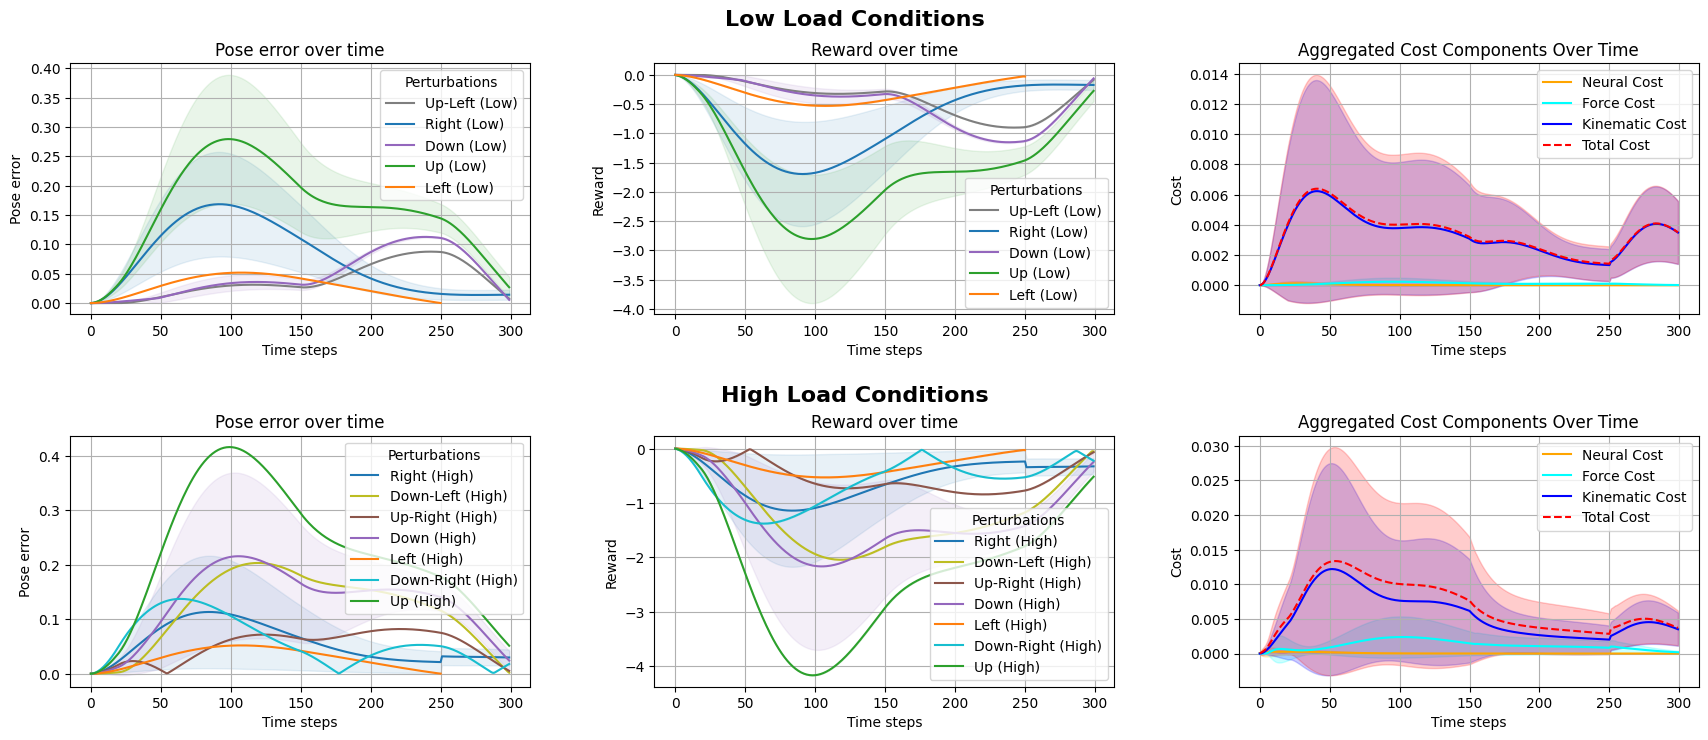

In [71]:
# Plot the results
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # Create a 2x3 grid of subplots

# Plot for low load conditions (first row)
plot_pose_error(axes[0, 0], low_load_results)
plot_reward(axes[0, 1], low_load_results)
plot_costs(axes[0, 2], [epoch_costs for i, epoch_costs in enumerate(epoch_costs_over_time) if epoch_metadata[i]["load"] == "Low"])

# Plot for high load conditions (second row)
plot_pose_error(axes[1, 0], high_load_results)
plot_reward(axes[1, 1], high_load_results)
plot_costs(axes[1, 2], [epoch_costs for i, epoch_costs in enumerate(epoch_costs_over_time) if epoch_metadata[i]["load"] == "High"])

# Add suptitles for each row
fig.text(0.5, 0.95, "Low Load Conditions", ha="center", fontsize=16, fontweight="bold")
fig.text(0.5, 0.48, "High Load Conditions", ha="center", fontsize=16, fontweight="bold")

# Adjust layout
plt.tight_layout(h_pad=4.0, pad=4.0)
plt.show()

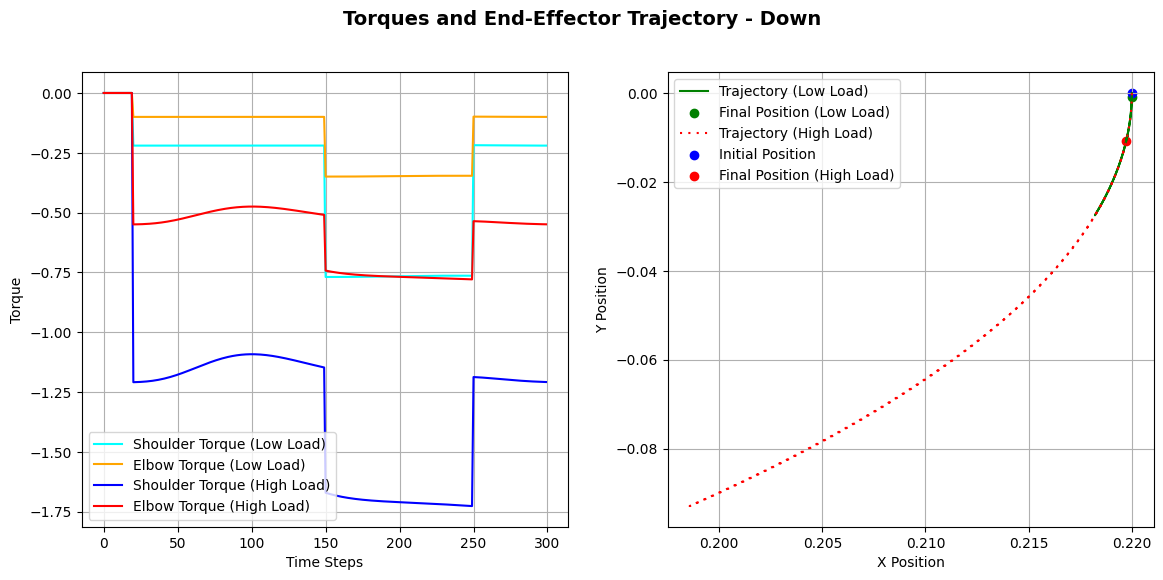

In [73]:
plot_selected_epochs(epoch_metadata, epoch_qpos_over_time, epoch_external_loads)